<a href="https://colab.research.google.com/github/mjamagos/Flower-Classification/blob/main/FlowerClassification_Lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%pip install -q "tensorflow-datasets==4.9.10" "tensorflow-metadata==1.17.1" "protobuf==5.29.6"

In [2]:
%pip install -q importlib-resources

**Step 1: Data Acquisition**

---
We loaded the TF Flowers dataset and resized all images to 64 × 64 pixels so the model gets images of the same size. We changed the images and labels into NumPy arrays, then divided them into 80% training data and 20% testing data while keeping similar amounts of each flower type. Finally, we printed the class names and array shapes to make sure the data was prepared correctly.


In [3]:
# Data Acquisition: TF Flowers
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
from sklearn.model_selection import train_test_split

dataset, info = tfds.load(
    "tf_flowers",
    split="train",
    as_supervised=True,
    with_info=True
)

class_label = info.features["label"].names

images = []
labels = []

for image, label in dataset:
    # Give all images same size before combining
    image = tf.image.resize(image, (64, 64))
    images.append(image.numpy().astype("uint8"))
    labels.append(int(label.numpy()))

X = np.array(images)
y = np.array(labels)

train_x, test_x, train_y, test_y = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

del images, labels, X, y

print("Classes:", class_label)
print("X_train:", train_x.shape)
print("Y_train:", train_y.shape)
print("X_test:", test_x.shape)
print("Y_test:", test_y.shape)

Classes: ['dandelion', 'daisy', 'tulips', 'sunflowers', 'roses']
X_train: (2936, 64, 64, 3)
Y_train: (2936,)
X_test: (734, 64, 64, 3)
Y_test: (734,)


**Step 2: Exploratory Data Analysis (EDA)**

---

We scaled the pixel values to 0–1 to prepare the images for training. For EDA, we displayed 16 sample images with their flower labels to inspect their appearance and check that the labels match. Finally, we printed the array shapes to confirm that scaling preserved the image dimensions.


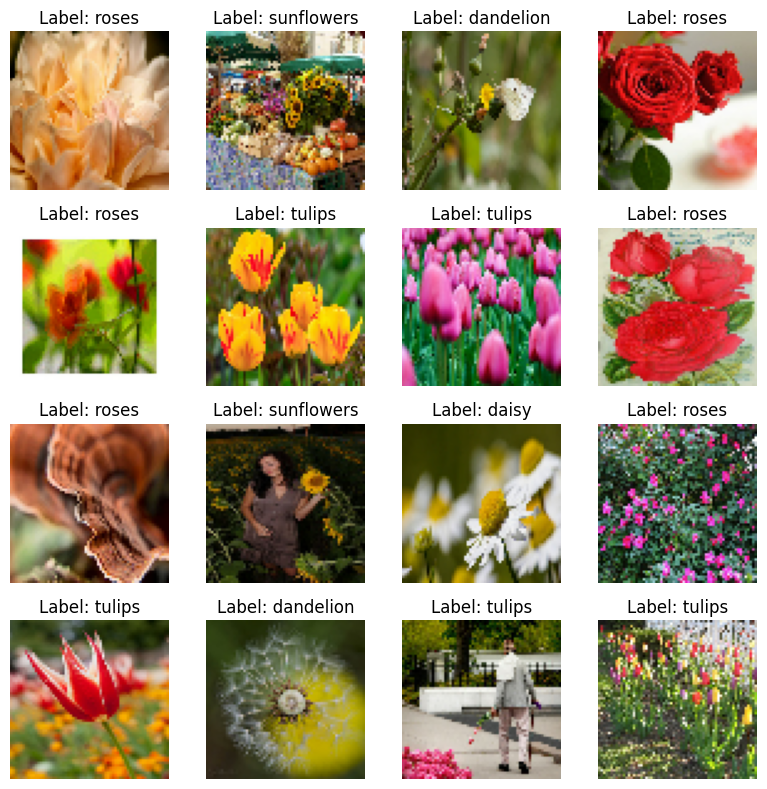

train_x shape after scaling: (2936, 64, 64, 3)
test_x shape after scaling: (734, 64, 64, 3)


In [4]:
import matplotlib.pyplot as plt

# Scale flower image pixels from 0–255 to 0–1.
train_x = train_x.astype("float32") / 255.0
test_x = test_x.astype("float32") / 255.0

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, 1 + i)
    plt.imshow(train_x[i])
    plt.title(f"Label: {class_label[train_y[i]]}")
    plt.axis("off")

plt.tight_layout()
plt.show()

print("train_x shape after scaling:", train_x.shape)
print("test_x shape after scaling:", test_x.shape)

**Step 3: Data Preprocessing**

---
We resized the images from 64 × 64 to 96 × 96 pixels to match our MobileNetV2 configuration and converted their pixel values from 0–1 to −1–1 because this is the range the pretrained model expects. We added random horizontal flipping during training to help the model recognize flowers facing different directions and reduce overfitting. Finally, we set a random seed to make training results more reproducible.



In [6]:
import keras
from keras import layers

keras.utils.set_random_seed(42)

# The images have already been normalized to 0–1.
inputs = keras.Input(shape=(64, 64, 3))

x = layers.Resizing(96, 96)(inputs)
x = layers.RandomFlip("horizontal")(x)
x = layers.Rescaling(2.0, offset=-1.0)(x)

**Step 4: Modelling**

---
We used MobileNetV2 pretrained on ImageNet to recognize useful image patterns without learning everything from scratch. We froze its existing weights to preserve that knowledge, summarized its features using global average pooling, and added dropout to reduce overfitting. A softmax output layer predicts the five flower categories.

We trained the classifier using Adam and sparse categorical cross-entropy since our labels are numbers for flower types. Training lasts up to 20 rounds in groups of 32, with 30% of the training data set aside for checking progress. We lower the learning rate when progress stops, and early stopping avoids extra training by restoring the best weights.




In [7]:
from keras.callbacks import EarlyStopping, ReduceLROnPlateau

base_model = keras.applications.MobileNetV2(
    input_shape=(96, 96, 3),
    include_top=False,
    weights="imagenet"
)
base_model.trainable = False

x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(5, activation="softmax")(x)

model = keras.Model(inputs, outputs)

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

history = model.fit(
    train_x,
    train_y,
    epochs=20,
    batch_size=32,
    validation_split=0.3,
    callbacks=[reduce_lr, early_stop]
)

print(
    f"Best validation accuracy: "
    f"{max(history.history['val_accuracy']):.2%}"
)

Epoch 1/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 23s 291ms/step - accuracy: 0.5620 - loss: 1.2188 - val_accuracy: 0.7571 - val_loss: 0.6305 - learning_rate: 0.0010
Epoch 2/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 13s 194ms/step - accuracy: 0.7698 - loss: 0.6429 - val_accuracy: 0.8025 - val_loss: 0.5333 - learning_rate: 0.0010
Epoch 3/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 22s 224ms/step - accuracy: 0.8151 - loss: 0.5158 - val_accuracy: 0.8150 - val_loss: 0.5045 - learning_rate: 0.0010
Epoch 4/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 222ms/step - accuracy: 0.8491 - loss: 0.4424 - val_accuracy: 0.8286 - val_loss: 0.4838 - learning_rate: 0.0010
Epoch 5/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 21s 225ms/step - accuracy: 0.8667 - loss: 0.3839 - val_accuracy: 0.8286 - val_loss: 0.4875 - learning_rate: 0.0010
Epoch 6/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 20s 219ms/step - accuracy: 0.8686 - loss: 0.3425 - val_accuracy: 0.8309 - val_loss: 0.4743 - learning_rate: 0.0010
Epoch 7/20
65/65 ━━━━━━━━━━━━━━━━━━━━ 14s 220ms/step - accuracy: 0.8803 - loss: 0.

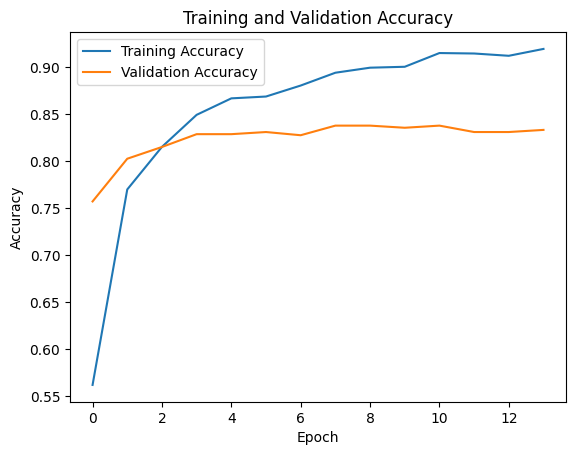

23/23 ━━━━━━━━━━━━━━━━━━━━ 3s 143ms/step - accuracy: 0.8515 - loss: 0.4180
Test loss: 0.4180
Test accuracy: 85.15%
23/23 ━━━━━━━━━━━━━━━━━━━━ 5s 162ms/step
Predictions shape: (734, 5)


In [8]:
import matplotlib.pyplot as plt

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Training and Validation Accuracy")
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

# Evaluate on the test images.
test_loss, test_accuracy = model.evaluate(test_x, test_y)

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.2%}")

# Predict probabilities for each flower category.
predictions = model.predict(test_x)

print("Predictions shape:", predictions.shape)

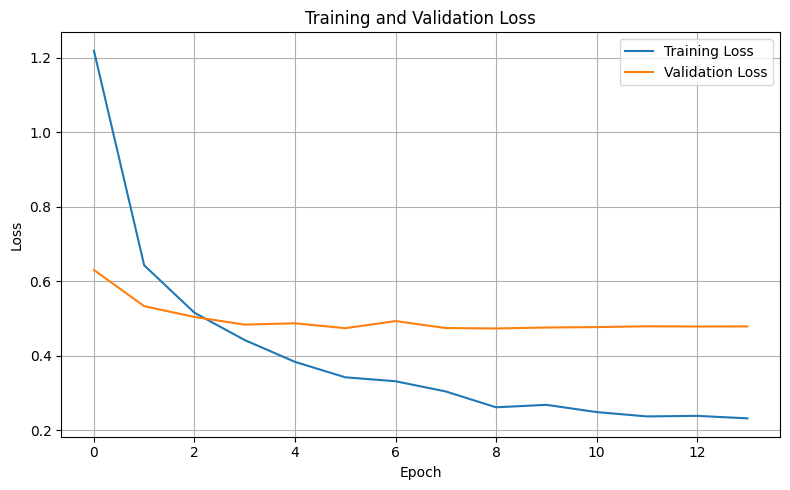

In [9]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

**Step 5: Perform Predictions**

---

We displayed 16 test images with their predicted and actual flower labels to visually check the model’s results. For each image, we selected the category with the highest predicted probability, allowing us to easily identify correct predictions and mistakes.

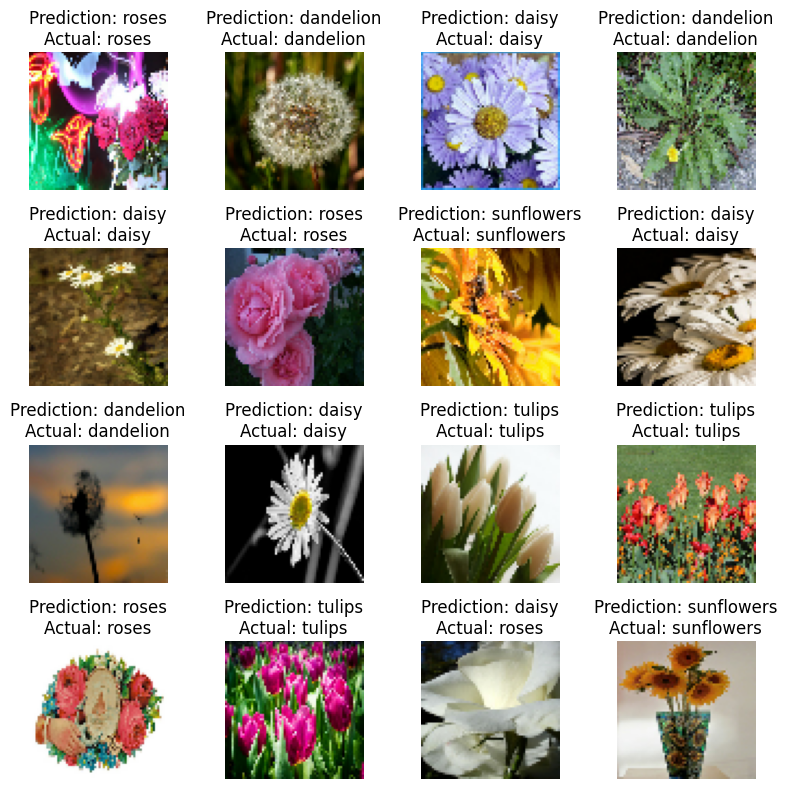

In [10]:
import numpy as np
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 8))

for i in range(16):
    plt.subplot(4, 4, i + 1)
    plt.imshow(test_x[i])

    predicted_label = class_label[np.argmax(predictions[i])]
    actual_label = class_label[test_y[i]]

    plt.title(f"Prediction: {predicted_label}\nActual: {actual_label}")
    plt.axis("off")

plt.tight_layout()
plt.show()

**Step 6: Model Evaluation**

---
Confusion Matrix: We compared the predicted and actual flower labels to find out which types the model gets right and which ones it mixes up. The diagonal shows the correct guesses, while the other boxes show the errors.

Classification Report: We measured precision, recall, and F1-score for each flower type to check how well the model works beyond just overall accuracy and to find which types need more work.

ROC AUC Scores: We checked how well the model tells each flower type apart from the others using its prediction chances. The macro-average combines these scores by treating all types equally.

ROC Curves: We drew graphs showing the true positive rate versus the false positive rate at different cutoffs to see how well the model tells each type apart. Curves near the top-left corner mean better results, while the diagonal line means guessing randomly.


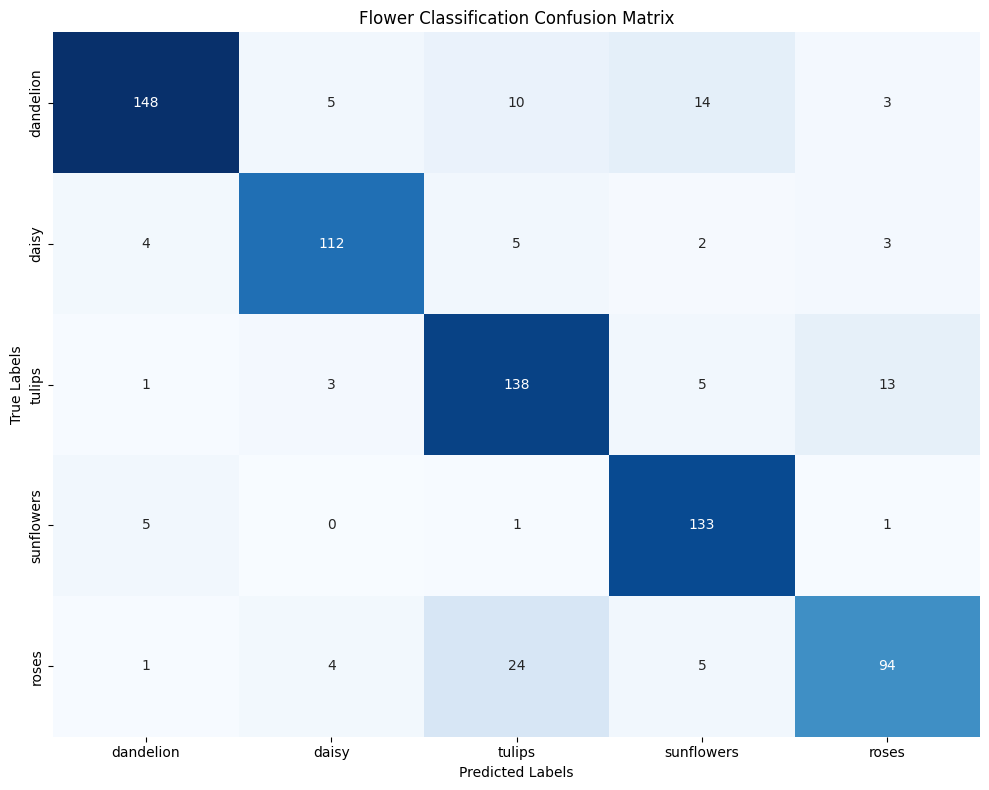

In [11]:
from sklearn.metrics import confusion_matrix
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

predicted_labels = np.argmax(predictions, axis=1)

cm = confusion_matrix(
    test_y,
    predicted_labels,
    labels=np.arange(len(class_label))
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=class_label,
    yticklabels=class_label
)

plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Flower Classification Confusion Matrix')
plt.tight_layout()
plt.show()

In [12]:
from sklearn.metrics import classification_report

report = classification_report(
    test_y,
    predicted_labels,
    labels=np.arange(len(class_label)),
    target_names=class_label,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

   dandelion       0.93      0.82      0.87       180
       daisy       0.90      0.89      0.90       126
      tulips       0.78      0.86      0.82       160
  sunflowers       0.84      0.95      0.89       140
       roses       0.82      0.73      0.78       128

    accuracy                           0.85       734
   macro avg       0.85      0.85      0.85       734
weighted avg       0.86      0.85      0.85       734



In [13]:
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import label_binarize
import numpy as np

# Convert actual labels into one-hot encoding.
y_test_bin = label_binarize(
    test_y,
    classes=np.arange(len(class_label))
)

# Calculate one-vs-rest ROC AUC for each flower category.
roc_auc_scores = roc_auc_score(
    y_test_bin,
    predictions,
    average=None
)

for name, score in zip(class_label, roc_auc_scores):
    print(f"ROC AUC for {name}: {score:.4f}")

# Give each flower category equal weight.
macro_roc_auc = roc_auc_score(
    y_test_bin,
    predictions,
    average="macro"
)

print(f"\nMacro-average ROC AUC: {macro_roc_auc:.4f}")

ROC AUC for dandelion: 0.9768
ROC AUC for daisy: 0.9895
ROC AUC for tulips: 0.9651
ROC AUC for sunflowers: 0.9854
ROC AUC for roses: 0.9721

Macro-average ROC AUC: 0.9778


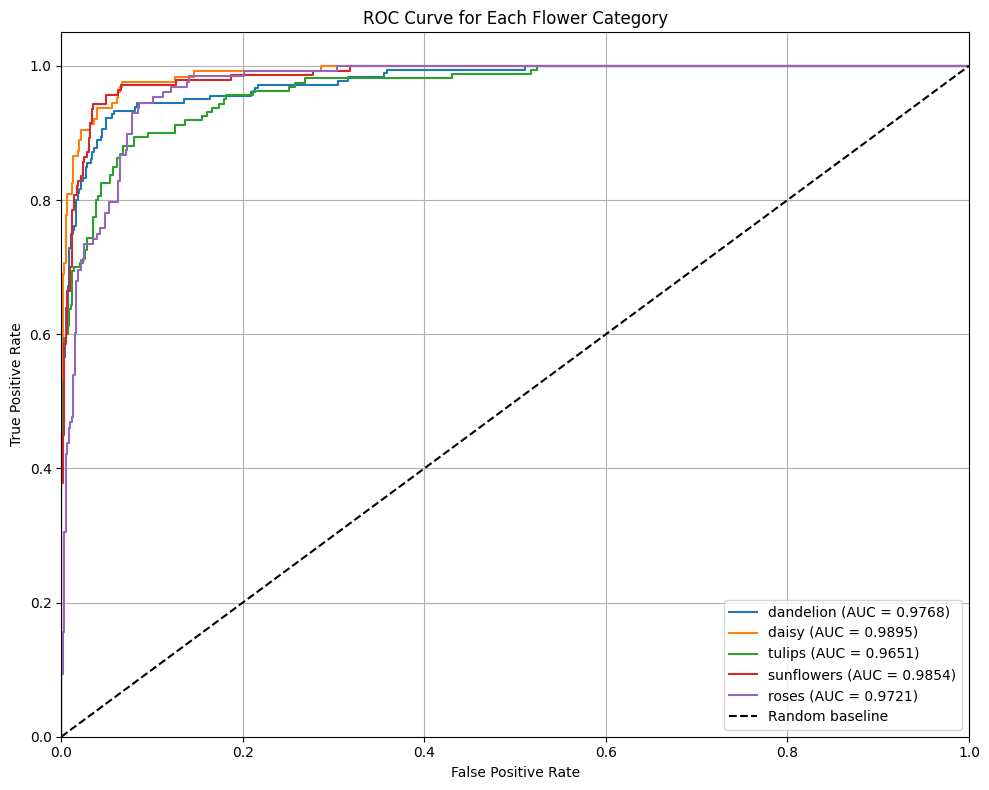

In [14]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

for i, name in enumerate(class_label):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        predictions[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"{name} (AUC = {roc_auc:.4f})"
    )

plt.plot([0, 1], [0, 1], "k--", label="Random baseline")

plt.title("ROC Curve for Each Flower Category")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

**Step 7: Deployment**

In [15]:
import tensorflow as tf
import json

# Convert the trained model to TensorFlow Lite.
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the converted model.
with open("flower_classifier.tflite", "wb") as file:
    file.write(tflite_model)

# Save the flower labels in the correct output order.
with open("flower_labels.json", "w") as file:
    json.dump(class_label, file)

print("Model saved as flower_classifier.tflite")
print("Labels saved as flower_labels.json")

Saved artifact at '/tmp/tmp1lb5c0cr'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 64, 64, 3), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 5), dtype=tf.float32, name=None)
Captures:
  135875252720016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135875251082768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135875251082576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135875251082384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135875251084112: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135875251079888: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135875251284368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135875251274576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135875251285712: TensorSpec(shape=(), dtype=tf.resource, name=None)
  135875251278608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  13587525258664

In [16]:
%pip install -q gradio

import tensorflow as tf
import numpy as np
import gradio as gr
import json
import threading

# Load the saved model.
interpreter = tf.lite.Interpreter(
    model_path="flower_classifier.tflite"
)
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

# Read the required image size from the model.
height = int(input_details[0]["shape"][1])
width = int(input_details[0]["shape"][2])

# Load labels in the same order used during training.
with open("flower_labels.json", "r") as file:
    class_names = json.load(file)

interpreter_lock = threading.Lock()

def classify_image(image):
    if image is None:
        raise gr.Error("Please upload a flower image first.")

    # Convert to RGB and match the training preprocessing.
    img = np.array(image.convert("RGB"))
    img = tf.image.resize(img, (height, width)).numpy()
    img = img.astype("uint8").astype("float32") / 255.0
    img = np.expand_dims(img, axis=0)

    # Process one prediction at a time.
    with interpreter_lock:
        interpreter.set_tensor(input_details[0]["index"], img)
        interpreter.invoke()
        scores = interpreter.get_tensor(
            output_details[0]["index"]
        )[0]

    return {
        name: float(scores[i])
        for i, name in enumerate(class_names)
    }

demo = gr.Interface(
    fn=classify_image,
    inputs=gr.Image(
        type="pil",
        image_mode="RGB",
        label="Upload a flower image"
    ),
    outputs=gr.Label(
        num_top_classes=5,
        label="Predictions"
    ),
    title="Flower Image Classifier",
    description=(
        "Upload a photo of a daisy, dandelion, rose, sunflower, "
        "or tulip. The model chooses among these five categories, "
        "even if the image shows something else."
    )
)

demo.launch(share=True, debug=True)

/usr/local/lib/python3.13/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://36d9a7296395e4ce85.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://36d9a7296395e4ce85.gradio.live


In [17]:
import os
import numpy as np
from PIL import Image

train_dir = "flower_images/train"
test_dir = "flower_images/test"

def save_images(images, labels, directory):
    for i, image in enumerate(images):
        # Convert normalized pixels back to 0–255 for saving.
        pixels = np.clip(
            np.rint(image * 255.0), 0, 255
        ).astype("uint8")

        img = Image.fromarray(pixels)

        flower_name = class_label[int(labels[i])]
        label_dir = os.path.join(directory, flower_name)
        os.makedirs(label_dir, exist_ok=True)

        img.save(os.path.join(label_dir, f"{i}.png"))

save_images(train_x, train_y, train_dir)
save_images(test_x, test_y, test_dir)

print("Flower images saved to 'flower_images'.")

Flower images saved to 'flower_images'.
